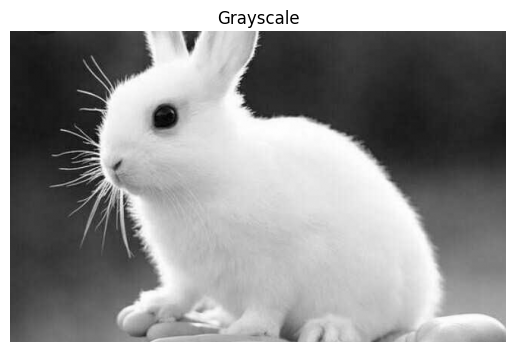

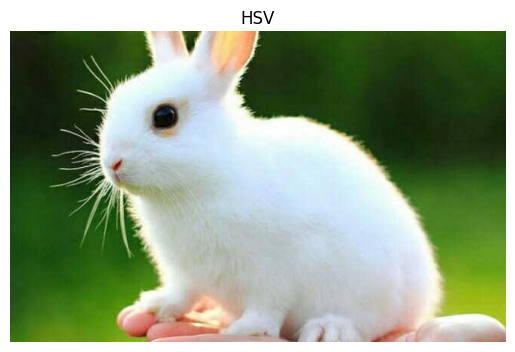

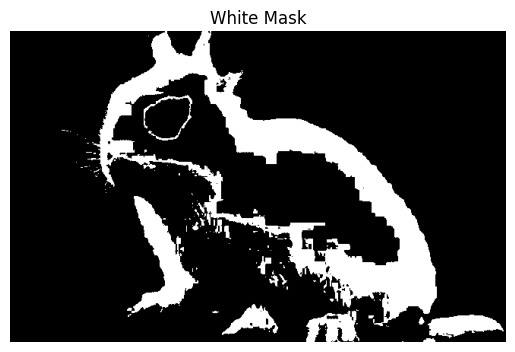

In [28]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\rabbit.jpeg')  
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for matplotlib

# Helper function to display images
def show(title, img):
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(title)
    plt.axis('off')
    plt.show()

# 1. Color Space Conversions
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
show('Grayscale', gray)
show('HSV', cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))

# 2. HSV Color Thresholding to extract white color
# Define lower and upper bounds for white in HSV
# Threshold for white color in HSV
lower_white = np.array([0, 0, 200])
upper_white = np.array([180, 30, 255])
mask_white = cv2.inRange(hsv, lower_white, upper_white)

# Apply the mask to get only white regions
res_white = cv2.bitwise_and(img, img, mask=mask_white)

# Show results
show('White Mask', mask_white)



##### HSV separates color intensity (V) and colorfulness (S), making it easier to detect white, which is high in brightness and low in saturation.



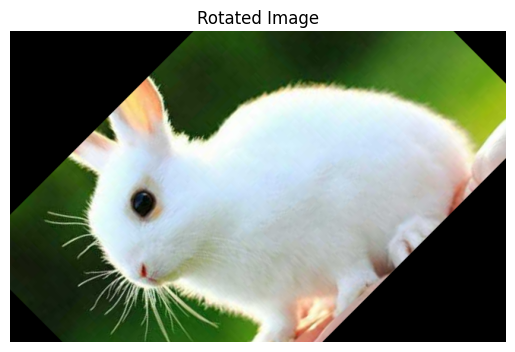

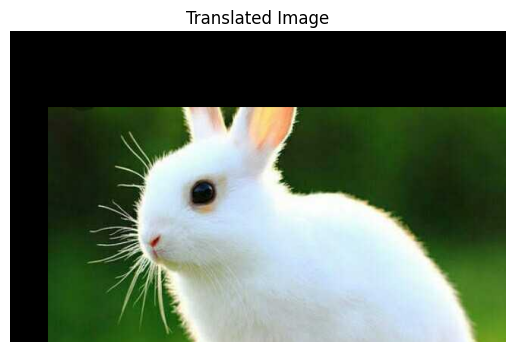

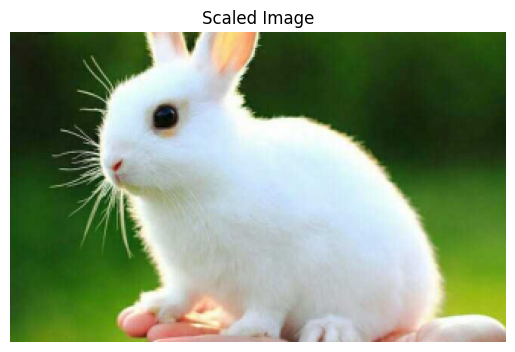

In [29]:
# Dimensions
(h, w) = img.shape[:2]
center = (w // 2, h // 2)

# 1️⃣ Rotation
# Rotate image 45 degrees around the center with scaling factor 1.0
M_rotate = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M_rotate, (w, h))
show('Rotated Image', cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))

# 2️⃣ Translation
# Translate image 50 pixels right and 100 pixels down
M_translate = np.float32([[1, 0, 50], [0, 1, 100]])
translated = cv2.warpAffine(img, M_translate, (w, h))
show('Translated Image', cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))

# 3️⃣ Scaling
# Resize the image to 50% of original dimensions
scaled = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
show('Scaled Image', cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))


## Affine Transformation
Maps the image using three pairs of corresponding points.

Affine transforms preserve parallelism of lines.

Useful for image shearing, skewing, or simulating viewpoint changes


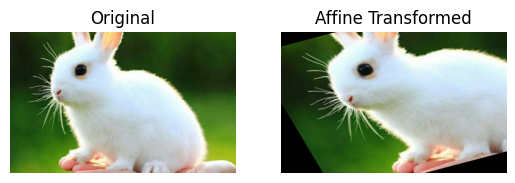

In [30]:
# 4️⃣ Affine Transformation
# Requires 3 points in original and destination
rows, cols, ch = img.shape
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])      # Source triangle
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])    # Destination triangle

M_affine = cv2.getAffineTransform(pts1, pts2)            # Get transformation matrix
dst_affine = cv2.warpAffine(img, M_affine, (cols, rows)) # Apply transformation

# Show input vs output
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.axis('off')
plt.subplot(122), plt.imshow(cv2.cvtColor(dst_affine, cv2.COLOR_BGR2RGB)), plt.title('Affine Transformed')
plt.axis('off')
plt.show()

## Perspective Transformation
- A perspective transformation is a type of geometric transformation that maps a quadrilateral in an image to another quadrilateral.
- Unlike affine transformations, perspective transforms can handle depth and perspective distortion

(<Axes: title={'center': 'Output'}>,
 Text(0.5, 1.0, 'Output'))

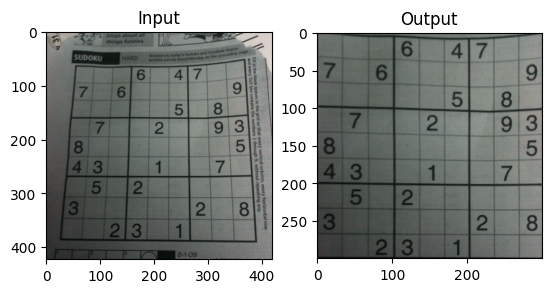

In [ ]:
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\sudoku.jpg')
assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols,ch = img.shape
 
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]]) #Coordinates of the distorted quadrilateral (corners of Sudoku)
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]]) # Coordinates of the output square (top-down view).
 
M = cv2.getPerspectiveTransform(pts1,pts2) #This creates a 3×3 transformation matrix
 
dst = cv2.warpPerspective(img,M,(300,300)) #ransforms the original image using the matrix M
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')

##  What is Image Thresholding?
Thresholding is a simple, yet powerful technique for image segmentation. It converts a grayscale image to a binary image based on a threshold value

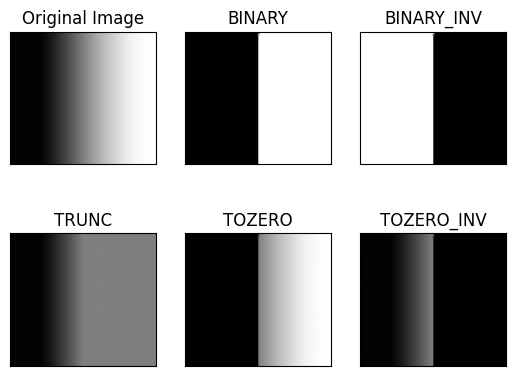

In [ ]:
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\gradient.jpeg', cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
# Apply various types of thresholding 
# # If pixel > thresh_value → set to max_value Else → set to 0
ret, thresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)        # >127 → 255, else 0
ret, thresh2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)    # >127 → 0, else 255
ret, thresh3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)         # >127 → 127, else original
ret, thresh4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)        # >127 → keep, else 0
ret, thresh5 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)    # >127 → 0, else keep
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
 
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

###  Adaptive Thresholding
Instead of a single threshold for the entire image, the threshold is calculated per small region (block) of the image. Useful when lighting is non-uniform.
#### Key Parameters:
adaptiveMethod:

- cv2.ADAPTIVE_THRESH_MEAN_C: mean of neighborhood

- cv2.ADAPTIVE_THRESH_GAUSSIAN_C: weighted sum using Gaussian window

- blockSize: size of neighborhood

- C: constant subtracted from the mean or weighted sum

### 🔹 Otsu's Binarization
Otsu’s method automatically determines an optimal global threshold value from the image histogram. Ideal for bimodal images (foreground and background peaks).

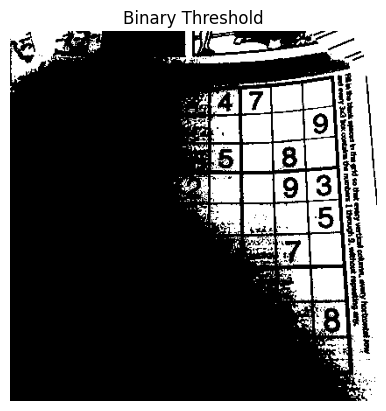

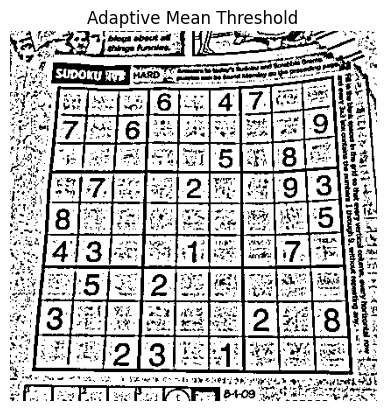

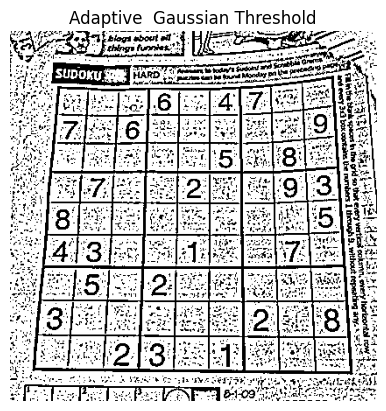

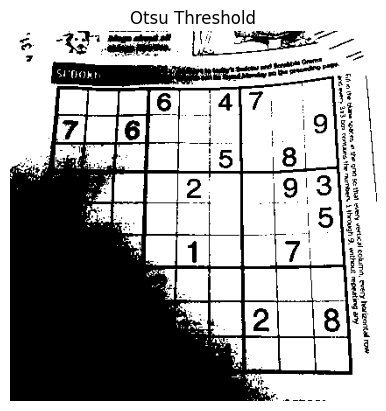

In [31]:
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\sudoku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 3. Image Thresholding
_, binary_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
adaptive_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)
adaptive_thresh_mean = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY, 11, 2)
_, otsu_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show('Binary Threshold', binary_thresh)
show('Adaptive Mean Threshold', adaptive_thresh_mean)
show('Adaptive  Gaussian Threshold', adaptive_thresh)
show('Otsu Threshold', otsu_thresh)



## 1. Gaussian Blur
Concept
Gaussian Blur uses a kernel that represents the shape of a Gaussian (bell-shaped) curve. The idea is to give more weight to the central pixels and less to the distant ones. This results in a smooth blur that reduces noise and detail.

## 2. Median Blur
 Concept
Median Blur replaces each pixel's value with the median of the neighboring pixel values. It's particularly effective in removing "salt-and-pepper" noise

## 3. Bilateral Filter
 Concept
Bilateral Filter smooths images while preserving edges. It considers both the spatial proximity and the intensity difference, ensuring that edges are not blurred

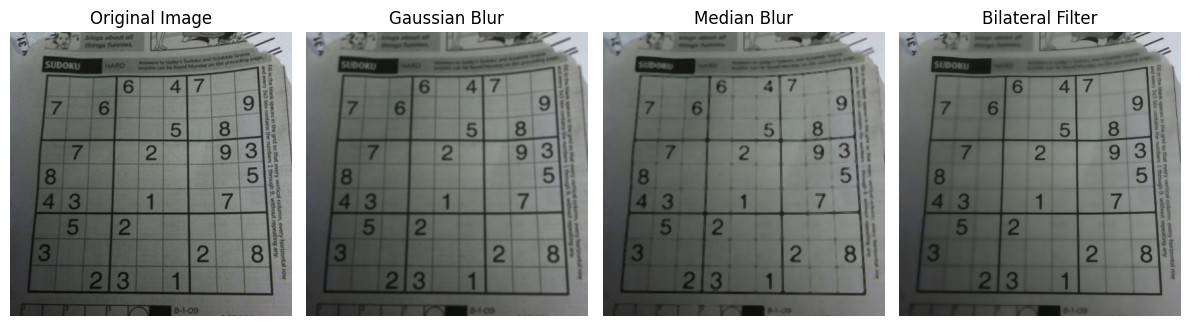

In [33]:
# 4. Blurring and Smoothing
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\sudoku.jpg')
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

gaussian = cv2.GaussianBlur(image_rgb, (5, 5), 0) # 0: Standard deviation in the X direction; if 0, it's calculated from the kernel size
median = cv2.medianBlur(image_rgb, 5) # 5: Kernel size for median filter, must be odd
bilateral = cv2.bilateralFilter(image_rgb, 9, 75, 75) # 9: Diameter of pixel neighborhood; 75: SigmaColor; 75: SigmaSpace

# Display original and filtered images using subplots
titles = ['Original Image', 'Gaussian Blur', 'Median Blur', 'Bilateral Filter']
images = [image_rgb, gaussian, median, bilateral]

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

##  Canny Edge Detection in OpenCV
Canny edge detection is a multi-stage algorithm to detect a wide range of edges in images. It's one of the most popular edge detection methods due to its accuracy and noise-resilience

- Low Thresholds detect more edges but are more sensitive to noise.

- High Thresholds give cleaner but fewer edges

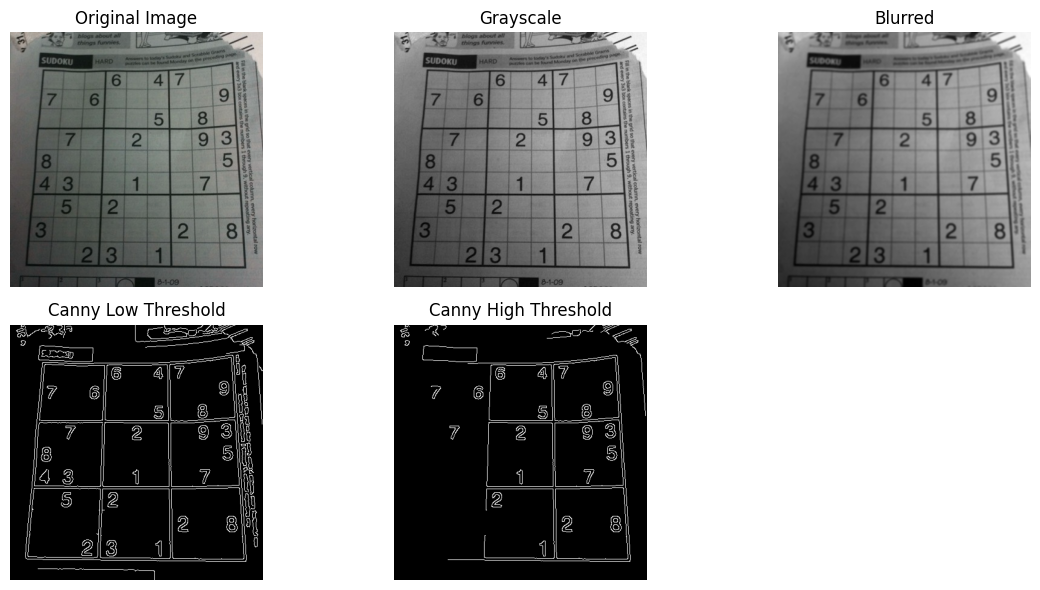

In [38]:

# Read and convert to grayscale
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\sudoku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)

# Apply Canny edge detection
edges_low = cv2.Canny(blurred, 50, 150)
edges_high = cv2.Canny(blurred, 100, 200)

# Display results in a subplot
titles = ['Original Image', 'Grayscale', 'Blurred', 'Canny Low Threshold', 'Canny High Threshold']
images = [img, gray, blurred, edges_low, edges_high]

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i] if i == 0 else images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


### morphological ops

Morphological operations are image processing techniques used primarily on binary images (black and white) to extract meaningful structures, clean up noise, or enhance specific patterns. These operations are based on shape and are performed using a structuring element (kernel).

#### 1. Erosion (cv2.erode)
- Effect: Shrinks the white regions.

- Use: Removes small white noise or detach connected objects.

- How: Kernel slides over the image and replaces the center pixel with the minimum pixel value under the kernel.

#### 2. Dilation (cv2.dilate)
- Effect: Expands the white regions.

- Use: Fills small holes in white objects or joins broken white parts.

- How: Kernel slides over and replaces the center pixel with the maximum value under the kernel.

#### 3. Opening (cv2.morphologyEx with MORPH_OPEN)
- Effect: Erosion followed by Dilation.

- Use: Removes small white noise while keeping the shape of large white objects.

#### 4. Closing (cv2.morphologyEx with MORPH_CLOSE)
- Effect: Dilation followed by Erosion.

- Use: Fills small black holes in the foreground (white objects).

#### 5. Cleaning
- Effect: Combination of Opening → Closing.

- Use: Provides a more aggressive denoising by performing both operations in sequence.

#### 6. Morphological Gradient
- Manual: Difference between Dilation and Erosion.

- Using cv2.morphologyEx: MORPH_GRADIENT

- Use: Useful for detecting the outlines of objects.





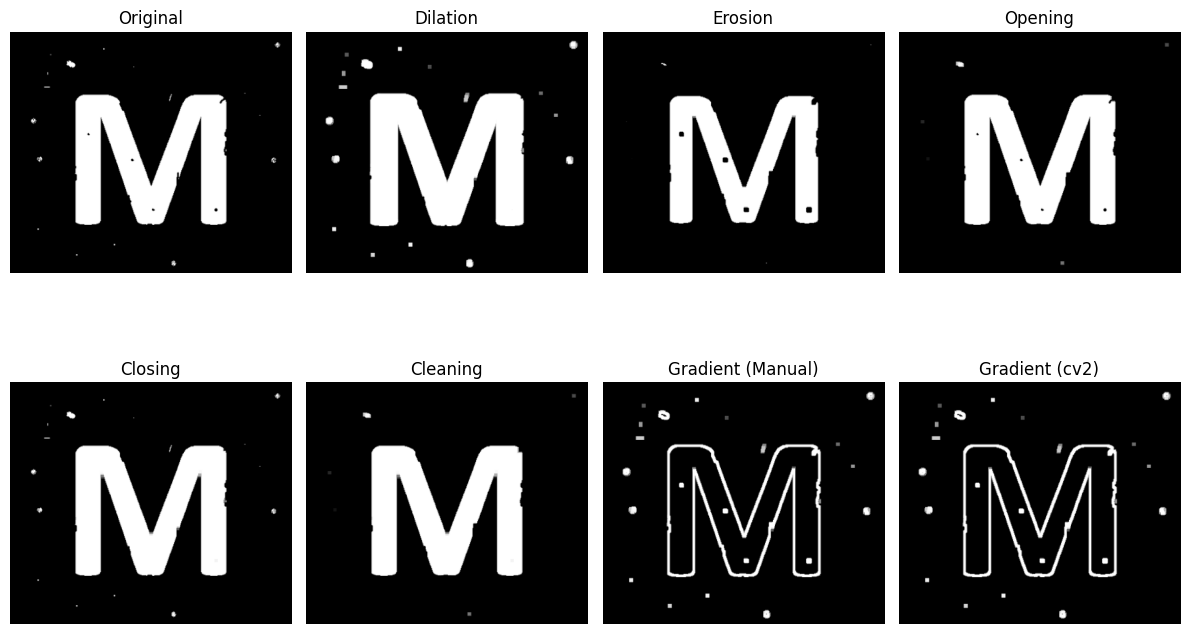

In [34]:

# Load the binary-like image (foreground in white, background in black)
img = cv2.imread(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\image_processing and Cnn nets\images\m.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define a kernel for morphological operations (5x5 square of ones)
kernel = np.ones((5, 5), np.uint8)

# Morphological Operations:
# Erosion: Shrinks white regions (foreground), removes white noise
erosion = cv2.erode(gray, kernel, iterations=1)

# Dilation: Expands white regions, fills small black holes
dilation = cv2.dilate(gray, kernel, iterations=1)

# Opening: Erosion followed by Dilation (useful for removing small white noise)
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

# Closing: Dilation followed by Erosion (useful for closing small black holes inside foreground)
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

# Cleaning: Further denoising using Opening followed by Closing
cleaning = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

# Morphological Gradient manually (dilation - erosion): outlines object boundaries
dilate_m = cv2.dilate(gray, kernel=kernel, iterations=1)
erode_m = cv2.erode(gray, kernel=kernel, iterations=1)
gradient_m = dilate_m - erode_m

# Morphological Gradient using OpenCV function
gradient_mo = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)

# Display Results using matplotlib subplots
plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(cleaning, cmap='gray')
plt.title('Cleaning')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(gradient_m, cmap='gray')
plt.title('Gradient (Manual)')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(gradient_mo, cmap='gray')
plt.title('Gradient (cv2)')
plt.axis('off')

plt.tight_layout()
plt.show()
